# CS 412 — Machine Learning
## Assignment 3 — Mini-Batch SGD, ReLU, and BCE

**Sabancı University | Spring 2026**

---

Submit as: `CS412-HW3-YourName.ipynb`  
Make sure all cell outputs and plots are visible before submitting.

### Student Information

In [1]:
NAME       = "Alp Eren Gül"   # e.g. "Ahmet Yilmaz"
STUDENT_ID = "32452"    # e.g. "12345"

print(f"Student : {NAME}")
print(f"ID      : {STUDENT_ID}")

Student : Alp Eren Gül
ID      : 32452


### Setup — Do Not Modify

In [2]:
# ============================================================
#  SETUP — DO NOT MODIFY
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
%matplotlib inline

BLUE   = '#60a5fa'
RED    = '#f87171'
GREEN  = '#4ade80'
AMBER  = '#fbbf24'
VIOLET = '#a78bfa'

np.random.seed(42)
print('Setup complete.')

Setup complete.


### Resources

If you are not familiar with matplotlib's multi-panel figures, these may help:
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
- https://matplotlib.org/stable/users/explain/axes/axes_intro.html
- https://medium.com/@elijahechekwu/understanding-matplotlib-subplots-a821abf55dc5

---
## Q1 — ADALINE with Mini-Batch SGD and Momentum [30 pts]

### Background

In class you implemented ADALINE with a **linear activation** and **batch gradient descent**. Recall the setup:

**Output:**
$$o = w_0 + w_1 x_1 + \cdots + w_d x_d = \mathbf{w}^T \mathbf{x}$$

**Cost function (MSE):**
$$E(\mathbf{w}) = \frac{1}{2N} \sum_{i=1}^{N} (t_i - o_i)^2$$

**Gradient:**
$$\frac{\partial E}{\partial w_j} = -\frac{1}{N} \sum_{i=1}^{N} (t_i - o_i)\, x_{ij}$$

**Batch update rule:**
$$w_j \leftarrow w_j + \alpha \cdot \frac{1}{N} \sum_{i=1}^{N} (t_i - o_i)\, x_{ij}$$

In batch gradient descent the gradient is computed over **all** $N$ samples before each weight update. This is stable but slow for large datasets.

**Mini-batch SGD** fixes this by shuffling the data and updating after each small batch of size $B$:

$$w_j \leftarrow w_j + \alpha \cdot \frac{1}{B} \sum_{i \in \text{batch}} (t_i - o_i)\, x_{ij}$$

**Momentum** further improves convergence by accumulating a velocity in the direction of persistent gradients. This dampens oscillations and speeds up convergence. The update rule becomes:

$$\Delta w_j^{(t)} = \mu \cdot \Delta w_j^{(t-1)} + \alpha \cdot \frac{1}{B} \sum_{i \in \text{batch}} (t_i - o_i)\, x_{ij}$$

$$w_j^{(t+1)} = w_j^{(t)} + \Delta w_j^{(t)}$$

where $\mu \in [0, 1)$ is the **momentum coefficient** (typically $0.9$) and $\Delta w_j^{(0)} = 0$. The same rule applies to the bias $b$:

$$\Delta b^{(t)} = \mu \cdot \Delta b^{(t-1)} + \alpha \cdot \frac{1}{B} \sum_{i \in \text{batch}} (t_i - o_i)$$

$$b^{(t+1)} = b^{(t)} + \Delta b^{(t)}$$

### Data

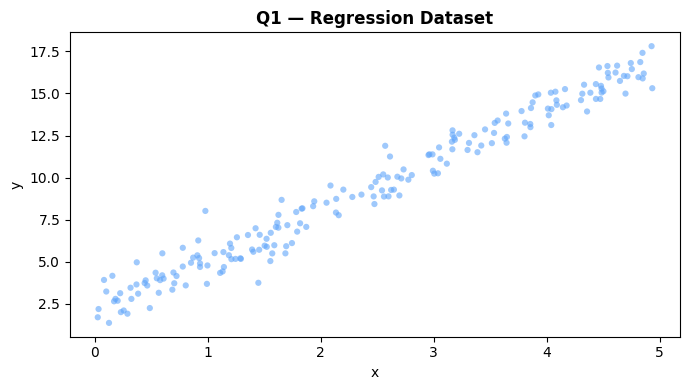

In [3]:
# ============================================================
#  DATA — DO NOT MODIFY
# ============================================================
np.random.seed(42)
N = 200
X_q1 = np.random.uniform(0, 5, (N, 1))
y_q1 = 3.0 * X_q1.squeeze() + 2.0 + np.random.randn(N) * 0.8

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_q1, y_q1, c=BLUE, s=20, alpha=0.6, edgecolors='none')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Q1 — Regression Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

### 1.1 — Implement `AdalineMomentum` [20 pts]

Complete the `fit` method below. Read the docstring carefully.

**Rules:**
- Only `numpy` is allowed. Do not use `sklearn`, `torch`, or any other ML library.
- Do not change the method signatures or the `# DO NOT MODIFY` blocks.

In [4]:
class AdalineMomentum:
    """
    ADALINE trained with mini-batch SGD and momentum.

    Parameters
    ----------
    lr         : float  -- learning rate (alpha)
    momentum   : float  -- momentum coefficient (mu), in [0, 1)
    n_epochs   : int    -- number of full passes over the data
    batch_size : int    -- number of samples per mini-batch
    """

    def __init__(self, lr=0.01, momentum=0.9, n_epochs=100, batch_size=32):
        # ---- DO NOT MODIFY ----
        self.lr            = lr
        self.momentum      = momentum
        self.n_epochs      = n_epochs
        self.batch_size    = batch_size
        self.w_            = None
        self.b_            = 0.0
        self.cost_history_ = []
        # -----------------------

    def net_input(self, X):
        # ---- DO NOT MODIFY ----
        return X @ self.w_ + self.b_
        # -----------------------

    def fit(self, X, y):
        """
        Train using mini-batch SGD with momentum.
        Refer to the background section for the update equations.

        Appends the full-dataset MSE to self.cost_history_ after each epoch.
        MSE: E = (1 / (2N)) * sum((y - net_input(X)) ** 2)
        """

        # ---- DO NOT MODIFY ----
        n_samples, n_features = X.shape
        self.w_ = np.zeros(n_features)
        self.b_ = 0.0
        self.cost_history_ = []
        # -----------------------

        # --- YOUR CODE HERE ---
        velocity_w = np.zeros(n_features)
        velocity_b = 0.0

        for _ in range(self.n_epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                output = self.net_input(X_batch)
                errors = y_batch - output

                grad_w = (X_batch.T @ errors) / len(X_batch)
                grad_b = np.mean(errors)

                velocity_w = self.momentum * velocity_w + self.lr * grad_w
                velocity_b = self.momentum * velocity_b + self.lr * grad_b

                self.w_ += velocity_w
                self.b_ += velocity_b

            mse = np.sum((y - self.net_input(X)) ** 2) / (2 * n_samples)
            self.cost_history_.append(mse)





        # ----------------------
        return self

    def predict(self, X):
        # ---- DO NOT MODIFY ----
        return self.net_input(X)
        # -----------------------

### 1.2 — Train and Visualize [10 pts]

Train your model and fill in the plotting cell. Both subplots are required for full credit.

In [5]:
# ---- DO NOT MODIFY ----
model_q1 = AdalineMomentum(lr=0.01, momentum=0.9, n_epochs=100, batch_size=32)
model_q1.fit(X_q1, y_q1)

print(f"Learned  :  w = {model_q1.w_[0]:.4f},  b = {model_q1.b_:.4f}")
print(f"Final MSE: {model_q1.cost_history_[-1]:.4f}")
# -----------------------

Learned  :  w = 2.9758,  b = 2.1016
Final MSE: 0.2990


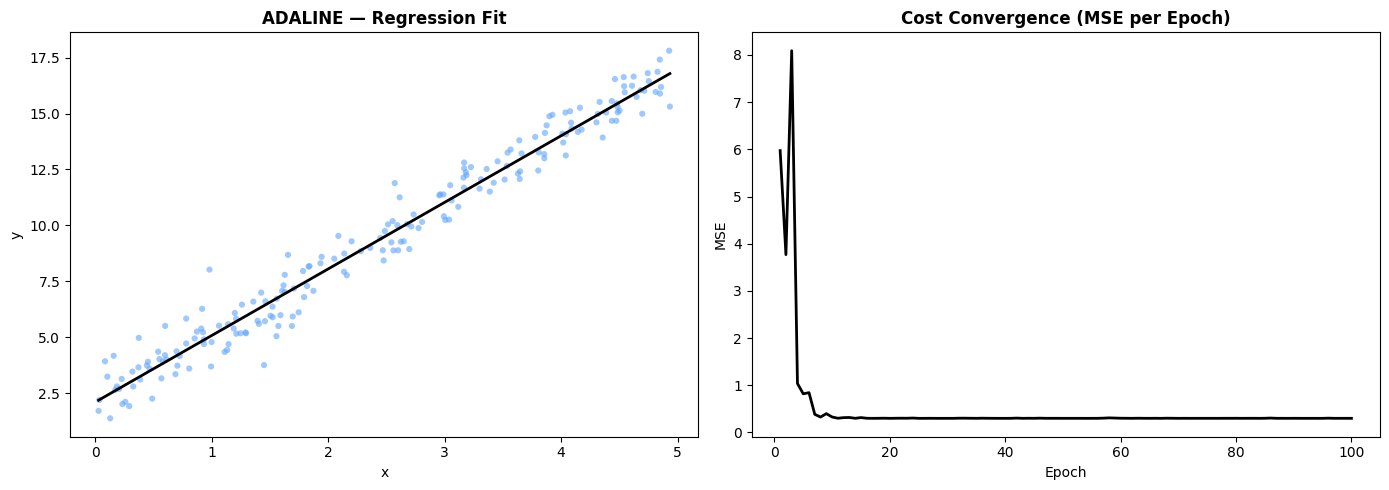

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- YOUR CODE HERE ---
# ax1: scatter the data points, then plot the learned regression line
# ax2: plot cost_history_ (y-axis) vs epoch number (x-axis)

ax1.scatter(X_q1[:, 0], y_q1, c=BLUE, s=20, alpha=0.6, edgecolors='none')

x_line = np.linspace(X_q1.min(), X_q1.max(), 200).reshape(-1, 1)
y_line = model_q1.predict(x_line)
ax1.plot(x_line, y_line, color='black', linewidth=2)

ax2.plot(range(1, len(model_q1.cost_history_) + 1), model_q1.cost_history_, color='black', linewidth=2)


# ----------------------

# ---- DO NOT MODIFY ----
ax1.set_title('ADALINE — Regression Fit', fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax2.set_title('Cost Convergence (MSE per Epoch)', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE')
fig.tight_layout()
plt.show()
# -----------------------

In [7]:
# ============================================================
#  AUTO-GRADER CHECKS — DO NOT MODIFY
# ============================================================
assert model_q1.w_ is not None,                                 "w_ is None — did you run fit?"
assert len(model_q1.cost_history_) == 100,                      "cost_history_ should have one entry per epoch (100 total)"
assert model_q1.cost_history_[-1] < model_q1.cost_history_[0], "Loss did not decrease"
print("All Q1 checks passed ✓")

All Q1 checks passed ✓


---
## Q2 — MLP with ReLU Hidden Layers [40 pts]

### Background

In class, backpropagation was derived for networks with **sigmoid** hidden activations:

$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad \sigma'(z) = \sigma(z)\,(1 - \sigma(z))$$

A well-known problem with sigmoid in deeper networks is the **vanishing gradient**: when a neuron saturates (output close to 0 or 1), $\sigma'(z) \approx 0$, and the gradient signal becomes negligibly small as it propagates back through earlier layers.

The standard solution is the **Rectified Linear Unit (ReLU)**:

$$\text{ReLU}(z) = \max(0,\, z)$$

Its derivative is:

$$\text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

Because the gradient through an active ReLU neuron is exactly 1 (not a small fraction), the vanishing gradient problem is greatly reduced.

### Network Architecture

You will implement a fully-connected MLP with:
- **Hidden layers**: ReLU activation
- **Output layer**: Sigmoid activation (binary classification)
- **Loss**: MSE, $\quad E = \dfrac{1}{2N}\displaystyle\sum_{i=1}^{N}(t_i - o_i)^2$

### Backpropagation with ReLU Hidden Layers

The chain rule derivation from lecture applies exactly as before. The only change is $f'(\text{net}_j)$ for hidden nodes.

**Output node** $k$ (sigmoid output, MSE loss):
$$\delta_k = (t_k - o_k) \cdot o_k\,(1 - o_k)$$

**Hidden node** $j$ (ReLU, propagating error from the next layer):
$$\delta_j = \text{ReLU}'(\text{net}_j) \cdot \sum_k w_{kj}\, \delta_k$$

where $\text{net}_j$ is the **pre-activation** value at node $j$ (before ReLU is applied), stored during the forward pass.

**Weight update** (one sample at a time):
$$\Delta w_{ji} = \alpha \cdot \delta_j \cdot o_i$$

where $o_i$ is the activation of the upstream node $i$ and $\alpha$ is the learning rate.

### Data

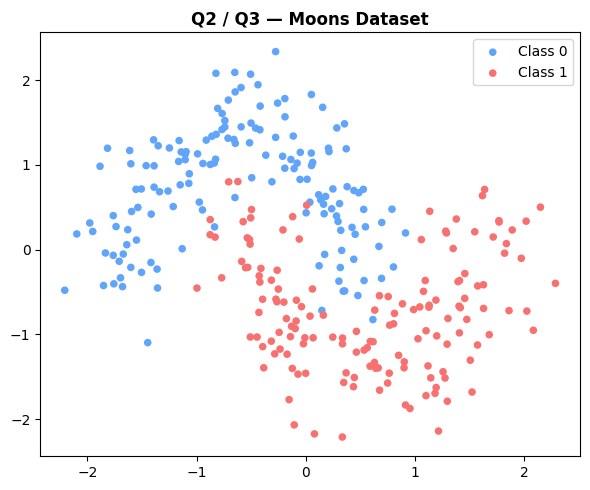

In [8]:
# ============================================================
#  DATA — DO NOT MODIFY
# ============================================================
np.random.seed(42)
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
scaler = StandardScaler()
X_moons = scaler.fit_transform(X_moons)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1],
           c=BLUE, s=30, edgecolors='none', label='Class 0')
ax.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1],
           c=RED,  s=30, edgecolors='none', label='Class 1')
ax.set_title('Q2 / Q3 — Moons Dataset', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 2.1 — Implement Activation Functions [5 pts]

In [9]:
def relu(z):
    # --- YOUR CODE HERE ---
    return np.maximum(0, z)
    # ----------------------

def relu_derivative(z):
    # --- YOUR CODE HERE ---
    return np.where(z > 0, 1.0, 0.0)
    # ----------------------

def sigmoid(z):
    # --- YOUR CODE HERE ---
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))
    # ----------------------

def sigmoid_derivative(a):
    # --- YOUR CODE HERE ---
    return a * (1.0 - a)
    # ----------------------


# ============================================================
#  AUTO-GRADER CHECKS — DO NOT MODIFY
# ============================================================
assert relu(np.array([-2., 0., 3.])).tolist() == [0., 0., 3.],           "relu failed"
assert relu_derivative(np.array([-1., 0., 2.])).tolist() == [0., 0., 1.], "relu_derivative failed"
assert abs(sigmoid(0) - 0.5) < 1e-9,                                      "sigmoid(0) should be 0.5"
assert abs(sigmoid_derivative(0.5) - 0.25) < 1e-9,                        "sigmoid_derivative(0.5) should be 0.25"
print("All activation checks passed ✓")

All activation checks passed ✓


### 2.2 — Implement the MLP [35 pts]

Complete the four methods marked below. The class supports an arbitrary number of hidden layers, all using ReLU. The output layer always uses sigmoid.

**Important:** The `backward` method must branch on `self.loss` to select the correct output delta. This is required for Q3 to work without any further changes.

In [10]:
class MLP:
    """
    Fully-connected MLP.
      Hidden layers : ReLU
      Output layer  : Sigmoid
      Loss          : 'mse' (Q2) or 'bce' (Q3)

    Parameters
    ----------
    layer_sizes : list of int
        Neuron counts for each layer including input and output.
        Example: [2, 16, 8, 1] means 2 inputs, two hidden layers
        (16 and 8 neurons), and 1 output neuron.
    lr       : float -- learning rate (alpha)
    n_epochs : int
    loss     : str  -- 'mse' or 'bce'
    """

    def __init__(self, layer_sizes, lr=0.01, n_epochs=200, loss='mse'):
        # ---- DO NOT MODIFY ----
        self.layer_sizes   = layer_sizes
        self.lr            = lr
        self.n_epochs      = n_epochs
        self.loss          = loss
        self.weights_      = []
        self.biases_       = []
        self.cost_history_ = []
        self._init_weights()
        # -----------------------

    def _init_weights(self):
        # ---- DO NOT MODIFY ----
        np.random.seed(42)
        for i in range(len(self.layer_sizes) - 1):
            fan_in  = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]
            W = np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
            b = np.zeros(fan_out)
            self.weights_.append(W)
            self.biases_.append(b)
        # -----------------------

    def forward(self, x):
        """
        Forward pass for a SINGLE sample x (1D array, shape (n_features,)).

        Returns
        -------
        activations : list of 1D arrays
            activations[0]  = x  (input, no activation applied)
            activations[l]  = output of layer l after applying its activation
            Length = len(layer_sizes)  (one per layer including input)

        pre_activations : list of 1D arrays
            pre_activations[l] = net input to layer l+1 BEFORE activation
                               = activations[l] @ weights_[l] + biases_[l]
            Length = len(weights_)  (one per weight matrix)

        Activation rules:
            Hidden layers (all but last weight matrix) : ReLU
            Output layer  (last weight matrix)         : sigmoid
        """
        # --- YOUR CODE HERE ---
        activations = [x]
        pre_activations = []

        a = x
        for l in range(len(self.weights_)):
            z = a @ self.weights_[l] + self.biases_[l]
            pre_activations.append(z)

            if l == len(self.weights_) - 1:
                a = sigmoid(z)
            else:
                a = relu(z)

            activations.append(a)

        return activations, pre_activations
        # ----------------------

    def backward(self, x, t, activations, pre_activations):
        """
        Backward pass for a SINGLE sample.
        Returns grad_w and grad_b: lists of arrays with the same
        shapes as self.weights_ and self.biases_.
        Use self.loss to select the correct output delta.
        """
        # --- YOUR CODE HERE ---
        grad_w = [None] * len(self.weights_)
        grad_b = [None] * len(self.biases_)

        output = activations[-1]
        target = np.array([t])

        if self.loss == 'mse':
            delta = (target - output) * sigmoid_derivative(output)
        elif self.loss == 'bce':
            delta = target - output
        else:
            raise ValueError("loss must be 'mse' or 'bce'")

        grad_w[-1] = np.outer(activations[-2], delta)
        grad_b[-1] = delta

        for l in range(len(self.weights_) - 2, -1, -1):
            delta = relu_derivative(pre_activations[l]) * (self.weights_[l + 1] @ delta)
            grad_w[l] = np.outer(activations[l], delta)
            grad_b[l] = delta

        return grad_w, grad_b
        # ----------------------

    def _compute_loss(self, y_true, y_pred):
        """
        Returns average loss. Supports self.loss == 'mse' and 'bce'.
        """
        # --- YOUR CODE HERE ---
        if self.loss == 'mse':
            return np.mean((y_true - y_pred) ** 2) / 2.0
        elif self.loss == 'bce':
            eps = 1e-12
            y_pred = np.clip(y_pred, eps, 1.0 - eps)
            return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        else:
            raise ValueError("loss must be 'mse' or 'bce'")
        # ----------------------

    def fit(self, X, y):
        """
        Train with SGD (one sample per update).
        Appends full-dataset loss to self.cost_history_ after each epoch.
        """
        # --- YOUR CODE HERE ---
        self.weights_ = []
        self.biases_ = []
        self.cost_history_ = []
        self._init_weights()

        n_samples = X.shape[0]

        for _ in range(self.n_epochs):
            indices = np.random.permutation(n_samples)

            for idx in indices:
                x_i = X[idx]
                t_i = y[idx]

                activations, pre_activations = self.forward(x_i)
                grad_w, grad_b = self.backward(x_i, t_i, activations, pre_activations)

                for l in range(len(self.weights_)):
                    self.weights_[l] += self.lr * grad_w[l]
                    self.biases_[l] += self.lr * grad_b[l]

            y_pred = self.predict_proba(X)
            self.cost_history_.append(self._compute_loss(y, y_pred))
                # ----------------------
        return self

    def predict_proba(self, X):
        # ---- DO NOT MODIFY ----
        return np.array([self.forward(x)[0][-1][0] for x in X])

    def predict(self, X):
        # ---- DO NOT MODIFY ----
        return (self.predict_proba(X) >= 0.5).astype(int)
        # -----------------------

In [11]:
# ============================================================
#  Train Q2 model — DO NOT MODIFY
# ============================================================
np.random.seed(42)
mlp_mse = MLP(layer_sizes=[2, 16, 8, 1], lr=0.05, n_epochs=300, loss='mse')
mlp_mse.fit(X_moons, y_moons)

acc_mse = np.mean(mlp_mse.predict(X_moons) == y_moons)
print(f"MSE model -- Final loss : {mlp_mse.cost_history_[-1]:.4f}")
print(f"MSE model -- Accuracy   : {acc_mse * 100:.1f}%")

MSE model -- Final loss : 0.0079
MSE model -- Accuracy   : 98.3%


In [12]:
# ============================================================
#  Helper — DO NOT MODIFY
# ============================================================
def plot_decision_boundary(model, X, y, title, ax):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    ax.scatter(X[y==0, 0], X[y==0, 1], c=BLUE, edgecolors='k', linewidths=0.3, label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c=RED,  edgecolors='k', linewidths=0.3, label='Class 1')
    ax.set_title(title)
    ax.legend()

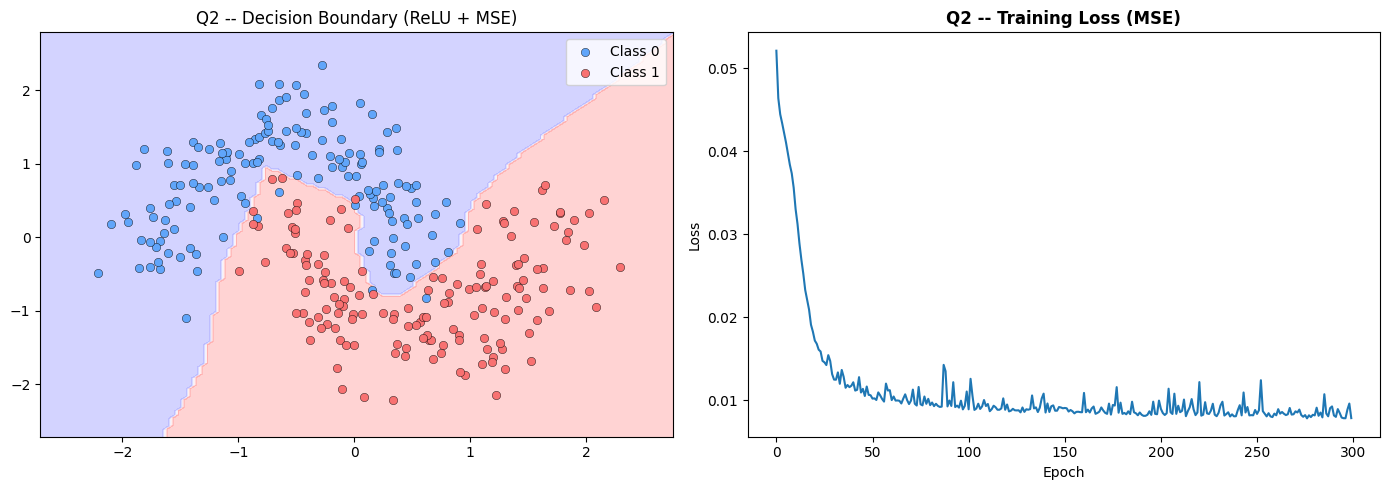

In [13]:
# ---- DO NOT MODIFY ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(mlp_mse, X_moons, y_moons, 'Q2 -- Decision Boundary (ReLU + MSE)', ax1)
ax2.plot(mlp_mse.cost_history_)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Q2 -- Training Loss (MSE)', fontweight='bold')
fig.tight_layout()
plt.show()
# -----------------------

In [14]:
# ============================================================
#  AUTO-GRADER CHECKS — DO NOT MODIFY
# ============================================================
assert len(mlp_mse.cost_history_) == 300,               "cost_history_ should have 300 entries"
assert mlp_mse.cost_history_[-1] < mlp_mse.cost_history_[0], "Loss did not decrease"
acts, pre_acts = mlp_mse.forward(X_moons[0])
assert len(acts) == 4,      "activations list should have 4 entries (input + 3 layers)"
assert len(pre_acts) == 3,  "pre_activations list should have 3 entries"
assert acts[-1].shape == (1,), "output activation should have shape (1,)"
print("All Q2 checks passed ✓")

All Q2 checks passed ✓


---
## Q3 — Binary Cross-Entropy Loss [30 pts]

### Background

In Q2 you used **MSE loss** for binary classification. The output delta for MSE + sigmoid is:

$$\delta_k^{\text{MSE}} = (t_k - o_k) \cdot o_k(1 - o_k)$$

The term $o_k(1-o_k)$ is the sigmoid derivative. When the network is very wrong — for example, $o_k \approx 0.01$ when $t_k = 1$ — the error $(t_k - o_k)$ is large, but $o_k(1-o_k) \approx 0.01 \times 0.99 \approx 0.01$ is tiny. The gradient is therefore small even when the prediction is badly wrong, which slows down learning.

**Binary Cross-Entropy (BCE)** is the standard loss for binary classification:

$$E = -\frac{1}{N} \sum_{i=1}^{N} \left[ t_i \log o_i + (1 - t_i) \log(1 - o_i) \right]$$

The derivative of BCE with respect to the output $o_k$ is:

$$\frac{\partial E}{\partial o_k} = -\frac{t_k}{o_k} + \frac{1 - t_k}{1 - o_k}$$

When this is combined with the sigmoid output node via the chain rule, the sigmoid derivative cancels exactly, and the output delta simplifies to:

$$\delta_k^{\text{BCE}} = t_k - o_k$$

The gradient is now proportional to the error alone — no saturation.

Everything else in backpropagation stays the same: hidden deltas still use the ReLU derivative, weight updates are unchanged.

### 3.1 — Train with BCE [5 pts]

In [15]:
# ---- DO NOT MODIFY ----
np.random.seed(42)
mlp_bce = MLP(layer_sizes=[2, 16, 8, 1], lr=0.05, n_epochs=300, loss='bce')
mlp_bce.fit(X_moons, y_moons)
print(f"BCE model -- Final loss : {mlp_bce.cost_history_[-1]:.4f}")
# -----------------------

BCE model -- Final loss : 0.0384


### 3.2 — Compare MSE vs BCE [15 pts]

Produce a 2×2 figure with all four subplots. All are required for full credit.

The top row should show decision boundaries (use `plot_decision_boundary`).  
The bottom row should show loss curves (epoch on x-axis, loss on y-axis).


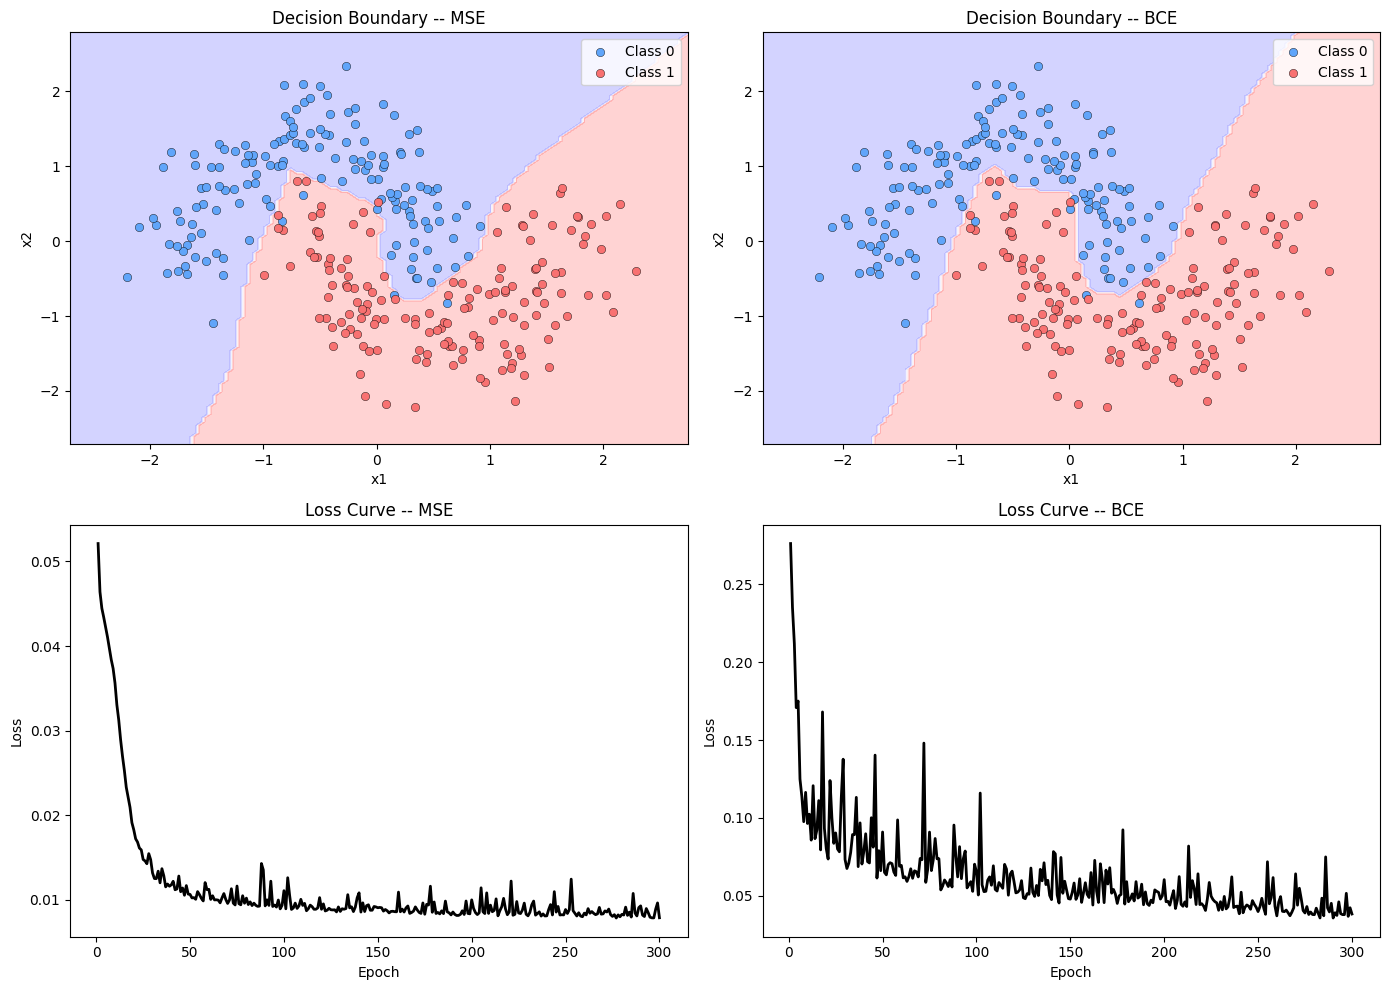

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- YOUR CODE HERE ---
# axes[0, 0] : decision boundary -- MSE model
# axes[0, 1] : decision boundary -- BCE model
# axes[1, 0] : loss curve        -- MSE model  (x: epoch, y: loss)
# axes[1, 1] : loss curve        -- BCE model  (x: epoch, y: loss)
# Add titles and axis labels to all four subplots.

plot_decision_boundary(mlp_mse, X_moons, y_moons, 'Decision Boundary -- MSE', axes[0, 0])
plot_decision_boundary(mlp_bce, X_moons, y_moons, 'Decision Boundary -- BCE', axes[0, 1])

axes[1, 0].plot(range(1, len(mlp_mse.cost_history_) + 1), mlp_mse.cost_history_, color='black', linewidth=2)
axes[1, 1].plot(range(1, len(mlp_bce.cost_history_) + 1), mlp_bce.cost_history_, color='black', linewidth=2)

axes[1, 0].set_title('Loss Curve -- MSE')
axes[1, 1].set_title('Loss Curve -- BCE')

axes[0, 0].set_xlabel('x1')
axes[0, 0].set_ylabel('x2')

axes[0, 1].set_xlabel('x1')
axes[0, 1].set_ylabel('x2')

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')

axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')


# ----------------------

# ---- DO NOT MODIFY ----
fig.tight_layout()
plt.show()
# -----------------------

In [17]:
# ============================================================
#  AUTO-GRADER CHECKS — DO NOT MODIFY
# ============================================================
assert len(mlp_bce.cost_history_) == 300,                        "BCE cost_history_ should have 300 entries"
assert mlp_bce.cost_history_[-1] < mlp_bce.cost_history_[0],    "BCE loss did not decrease"
print("All Q3 checks passed ✓")

All Q3 checks passed ✓


### 3.3 — Reflection [10 pts]

In the cell below, briefly answer: what differences do you observe between
the MSE and BCE loss curves? Is one clearly better than the other? Why or why not?

When we do classification tasks the BCE loss usually goes down faster and it is smoother than the MSE loss. This is because when we use sigmoid at the output the BCE loss gives the model a signal when it makes a bad prediction. The BCE loss is more useful for the model to learn from.

The MSE loss is different. The error in the MSE loss is affected by the sigmoid derivative. This means the updates to the model are smaller. As a result the model may learn slowly.

In our homework we used both loss functions. The model was able to learn a good decision boundary with both. So the MSE loss is not all bad.. Overall the BCE loss is better for binary classification tasks. The BCE loss helps the model learn effectively when it is training. The BCE loss is more suitable, for classification because it helps the model learn better.

---
## Submission Checklist

Before submitting, confirm the following:

- Your name and student ID are filled in at the top.
- You have run all cells top-to-bottom (Kernel → Restart & Run All).
- All plots are visible in the notebook output.
- All auto-grader cells print ✓.
- The file is named `CS412-HW3-YourName.ipynb`.